In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
# sim_name = f"SunMod_5k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)


#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]


# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

In [ ]:
def test_pixel_mapping():
    nside = 8  # 768 pixels
    p_mag = jnp.geomspace(0.01, 400, 10)  # Using 10 points for clarity
    
    # Create unit vectors in different directions
    theta_test = jnp.array([0, jnp.pi/4, jnp.pi/2, 3*jnp.pi/4, jnp.pi])
    phi_test = jnp.array([0, jnp.pi/2, jnp.pi, 3*jnp.pi/2])
    
    # Create cartesian components for each direction
    p_vec = jnp.zeros((len(theta_test), len(phi_test), len(p_mag), 3))
    for i, theta in enumerate(theta_test):
        for j, phi in enumerate(phi_test):
            p_vec = p_vec.at[i,j,:,0].set(p_mag * jnp.sin(theta) * jnp.cos(phi))
            p_vec = p_vec.at[i,j,:,1].set(p_mag * jnp.sin(theta) * jnp.sin(phi))
            p_vec = p_vec.at[i,j,:,2].set(p_mag * jnp.cos(theta))
    
    # Get pixels
    p_vec_mag = jnp.sqrt(jnp.sum(p_vec**2, axis=-1))
    p_unit = p_vec / p_vec_mag[..., None]
    
    theta = jnp.arccos(p_unit[..., 2])
    phi = jnp.arctan2(p_unit[..., 1], p_unit[..., 0])
    npix = 12 * nside * nside
    phi = jnp.where(phi < 0, phi + 2*jnp.pi, phi)
    pixels = jnp.clip(jnp.floor((npix * (1 - jnp.cos(theta)) * phi/(2*jnp.pi))), 0, npix-1).astype(int)
    
    print(pixels.shape)

    print("Pixel indices for different directions:")
    print("theta (rad) | phi (rad) | pixel")
    print("-" * 40)
    for i, theta in enumerate(theta_test):
        for j, phi in enumerate(phi_test):
            print(f"{theta:9.2f} | {phi:8.2f} | {pixels[i,j,0]}")
            
test_pixel_mapping()

### Precomputations

- Earth velocities from SunEarthGC_frame_coords_local(2024)
- 

### Step-by-step flowchart to arrive at modulations

1. Load neutrino velocity vectors, i.e. output from 1-year simulations.
2. Load Earth velocities.
3. Transform sim velocities into Earth frame
   (issue about boosting to be studied)
4. From here usual process: conversion to momentum, Liouville, integrate.


## Plotting annual modulations

*(densities computed in separate .py script)*

SunLock_test_grav_PSD_Earth_frame_wrtMW_int_pixels
days_dens shape: (31, 1, 5)


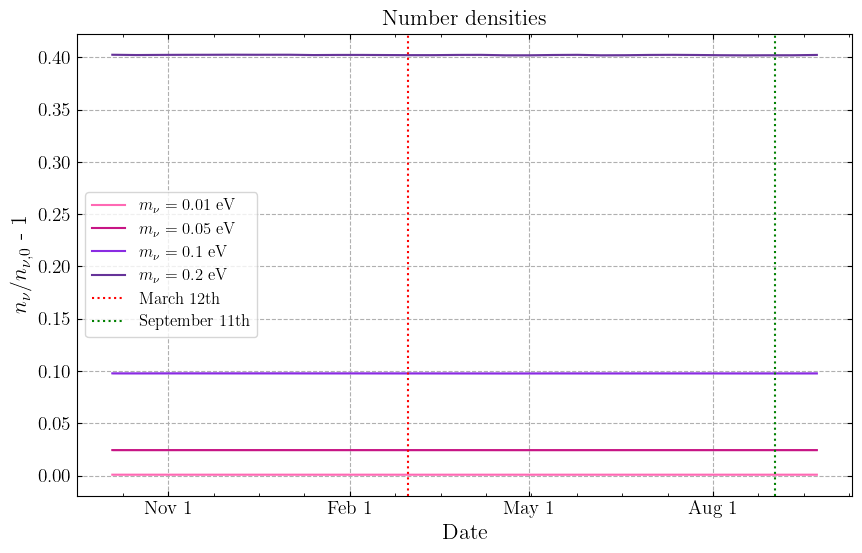

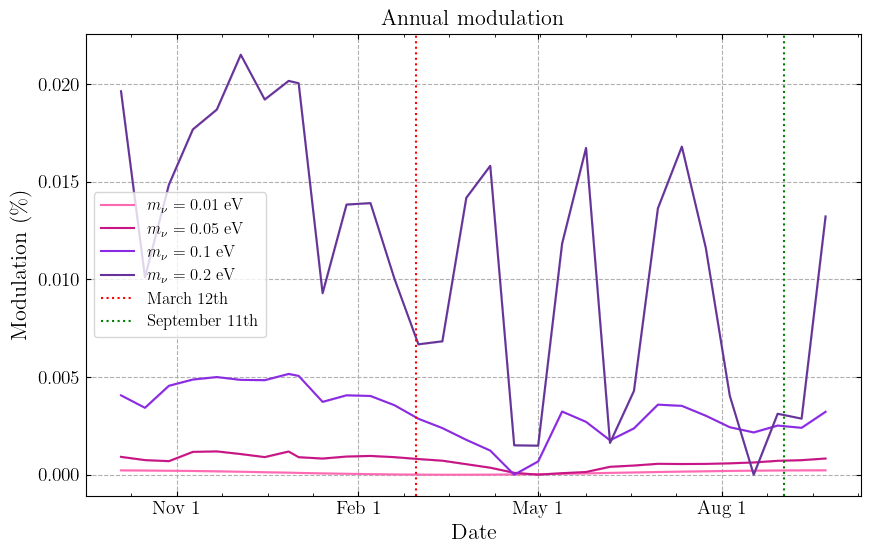

In [2]:
### ======= ###
### Version ###
### ======= ###

# sim_name = f"SunNoG"
sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
# prefix = "NoSun"
# prefix = "SunNoDM"

# Testing new interpolation routine
prefix = "SunLock_test"
# suffix = "_grav_PSD_int_pixels"
suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"

# Sun only
# prefix = "SunLock"

# Sun + DM halo gravity vector
# prefix = "SunLockDM"
#/including DM gravity in daily sims doesn't induce significant changes
#? but does using PSD from core sim, instead of FD, induce changes?

# versions that are ready are marked with #/

# Sun only (in "SunLock" frame, not Earth's), FD as boundary condition
# suffix = "_FD_PSD_int_pixels"  #/

# Earth's frame: Sun effect, FD_boosted with T_eff as boundary condition
# suffix = "_FD_PSD_Earth_frame_wrtSun_int_pixels"  #/

# Earth's frame: Sun effect, PSD from DM sim as boundary condition
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"  #/ 10 halos, most correct?
# suffix = "_grav_PSD_Earth_frame_int_pixels"  #/ Earth-rel-vel only

# (using CNB as rel. vel seems not right, as it would not correspond to the
# frame which the DM simulations, and the resulting PSD, are in...)
# suffix = "_grav_PSD_Earth_frame_wrtCNB_int_pixels"  #/ wrong rel. vel.?

# Earth's frame: Bound vs. unbound populations, using PSD from DM sim
# suffix = "_grav_PSD_Earth_frame_wrtMW_bound_int_pixels"  #/
# suffix = "_grav_PSD_Earth_frame_wrtMW_unbound_int_pixels"  #/

### =========== ###
### Load & Plot ###
### =========== ###

print(f"{prefix}{suffix}")
days_nums = jnp.load(f"{sim_folder}/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(f"{sim_folder}/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")
# (days, halos, masses)

if suffix == "_FD_PSD_int_pixels":
    print(f"\nSun clustering factors:")
    print(jnp.mean(days_dens[:,0,:], axis=0)/Params.N0_cm3-1)

SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    pdf_path=f"{fig_folder}/densities_{prefix}{suffix}",
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    pdf_path=f"{fig_folder}/modulation_{prefix}{suffix}",
)

## Deflection angles

In [ ]:
def calculate_deflection_angle(velocity_vectors):
    """
    Calculate the deflection angle between initial and final velocity vectors.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :return: numpy array of deflection angles in degrees
    """
    z0_vels = velocity_vectors[:, 0, :]
    z4_vels = velocity_vectors[:, -1, :]
    
    # Normalize the vectors
    z0_vels_norm = z0_vels / np.linalg.norm(z0_vels, axis=-1)[:, None]
    z4_vels_norm = z4_vels / np.linalg.norm(z4_vels, axis=-1)[:, None]
    
    # Calculate the dot product
    dot_product = np.sum(z0_vels_norm * z4_vels_norm, axis=-1)
    
    # Clip the dot product to [-1, 1] to avoid numerical errors
    dot_product_clipped = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians and convert to degrees
    angles = np.arccos(dot_product_clipped) * 180 / np.pi
    
    return angles


def analyze_and_plot_deflections(velocity_vectors, bins, exclude_zero):
    """
    Analyze deflection angles and create a plot with median and 1-sigma percentiles.
    The plot range is limited to the min and max found values.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :param exclude_zero: boolean, if True, exclude zero angles from analysis
    """
    deflection_angles = calculate_deflection_angle(velocity_vectors)
    
    if exclude_zero:
        deflection_angles = deflection_angles[deflection_angles > 0]
        if len(deflection_angles) == 0:
            print("No non-zero deflection angles found. Cannot perform analysis.")
            return

    median = np.median(deflection_angles)
    percentile_16 = np.percentile(deflection_angles, 16)
    percentile_84 = np.percentile(deflection_angles, 84)
    
    min_angle = np.min(deflection_angles)
    max_angle = np.max(deflection_angles)
    
    plt.figure(figsize=(10, 6))
    n, bins, patches = plt.hist(deflection_angles, bins=bins, edgecolor='black')
    plt.axvline(
        median, color='r', linestyle='dashed', linewidth=2, 
        label=f'Median: {median:.2f}°')
    plt.axvline(
        percentile_16, color='g', linestyle='dashed', linewidth=2, 
        label=f'16th percentile: {percentile_16:.2f}°')
    plt.axvline(
        percentile_84, color='g', linestyle='dashed', linewidth=2, 
        label=f'84th percentile: {percentile_84:.2f}°')
    
    plt.xlabel('Deflection Angle (degrees)')
    plt.ylabel('Frequency')
    title = 'Distribution of Deflection Angles'
    if exclude_zero:
        title += ' (Excluding Zero Angles)'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set x-axis limits to min and max found values
    plt.xlim(min_angle, max_angle)
    
    # Adjust y-axis to show full height of the tallest bar
    plt.ylim(0, max(n) * 1.1)
    
    
    print(f"Median deflection angle: {median:.2f}°")
    print(f"1-sigma range: {percentile_16:.2f}° - {percentile_84:.2f}°")
    print(f"Minimum deflection angle: {min_angle:.2f}°")
    print(f"Maximum deflection angle: {max_angle:.2f}°")
    if exclude_zero:
        print(f"Number of non-zero angles: {len(deflection_angles)}")
        print(f"Number of zero angles excluded: {len(velocity_vectors) - len(deflection_angles)}")
    
    plt.show()
    

# """
for day in range(0, 365, 24)[::10]:

    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    print(f"Day {day+1}")
    # sim_folder_local = f"sim_output/SunNoG"
    # sim_folder_local = f"sim_output/SunMod_1k"
    sim_folder_local = f"sim_output/SunMod_2k"
    # days_vecs_dir = f"{sim_folder}/EarthSun_frame_Dopri8"
    # days_vecs_dir = f"{sim_folder_local}/NoSun_vectors"
    days_vecs_dir = f"{sim_folder_local}/SunLock_frame"
    day_vels = jnp.load(
        f"{days_vecs_dir}/vectors_day{day+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
# """


"""
# For Dopri5_1k folder and DM halo files
for halo_i in range(3):

    print(f"Halo {halo_i+1}")
    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    sim_folder_local = f"sim_output/Dopri5_1k"
    day_vels = jnp.load(
        f"{sim_folder_local}/vectors_halo{halo_i+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
"""

In [ ]:
#
#? Questions?:
# - show that modulation curve peak is determined by relative velocity
# - virialisation/isotropy of bound CNB not good assumption?
#   and if all then for small percentage of [0.006, 0.7, 3.9, 12.4, 17.7]
#                                       for [0.01, 0.05, 0.1, 0.2,  0.3] eV